# Таблица payments

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [119]:
df_p = pd.read_csv('../raw_data/df_Payments.csv')

In [120]:
df_p.shape

(89316, 5)

In [121]:
df_p.size

446580

In [122]:
df_p.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [123]:
df_p.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              89316 non-null  str    
 1   payment_sequential    89316 non-null  int64  
 2   payment_type          89316 non-null  str    
 3   payment_installments  89316 non-null  int64  
 4   payment_value         89316 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 3.4 MB


In [124]:
df_p['payment_type'].nunique()

4

In [125]:
df_p['payment_type'].unique()

<StringArray>
['credit_card', 'wallet', 'voucher', 'debit_card']
Length: 4, dtype: str

In [126]:
# переведем данные в payment_type в тип "категория"
df_p['payment_type'] = df_p['payment_type'].astype('category')
df_p.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   order_id              89316 non-null  str     
 1   payment_sequential    89316 non-null  int64   
 2   payment_type          89316 non-null  category
 3   payment_installments  89316 non-null  int64   
 4   payment_value         89316 non-null  float64 
dtypes: category(1), float64(1), int64(2), str(1)
memory usage: 2.8 MB


In [127]:
df_p['payment_sequential'].unique()

array([ 1,  8,  2,  6,  3,  4,  9,  5, 23, 11, 18, 10,  7, 12, 13, 26, 15,
       14, 17, 24, 21, 20, 16, 19, 22, 29, 25, 28])

In [128]:
df_p['payment_installments'].unique()

array([ 1,  8,  4,  2,  5,  6, 10,  3,  7,  9, 18, 12, 24, 15, 11, 13, 21,
       16, 20, 14, 17, 23, 22,  0])

In [129]:
df_p.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25
3,bwJVWupf2keN,1,credit_card,2,27.79
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15


In [130]:
df_p.tail()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
89311,zlcLnXGgAabl,1,wallet,1,128.00
89312,IlTAoIkILwrq,1,wallet,1,106.86
89313,uA6oXfftGVmT,1,credit_card,1,376.39
89314,v3QtU6xlGDJp,1,voucher,1,48.05
89315,Xo1fqyXOC6CR,1,credit_card,10,211.93


In [131]:
df_p.sample(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
41202,0MuuqGsjol7E,1,credit_card,3,3.78
1498,ZQVJxqCGKphJ,1,credit_card,1,37.34
26926,1i2z3CVts83S,1,credit_card,1,272.64
56069,ba8mfE5i8peu,1,credit_card,4,152.11
48532,cv2GClgSEsmk,1,credit_card,2,209.08
79383,Z7SJyQsf0C8a,1,credit_card,5,210.42
56568,ZM05X3uDOijX,1,credit_card,3,14.67
83997,MH75jDr6mPXh,1,credit_card,1,75.21
18245,osRMHRfcv6Z7,1,credit_card,5,70.55
56390,n1GBUxSzg8jj,1,credit_card,5,132.84


In [132]:
df_p.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [133]:
df_p.nunique()

order_id                89316
payment_sequential         28
payment_type                4
payment_installments       24
payment_value           25520
dtype: int64

In [134]:
df_p.duplicated().sum()

np.int64(0)

In [135]:
df_p.describe()

,payment_sequential,payment_installments,payment_value
count,89316.000000,89316.000000,89316.000000
mean,1.099646,2.965717,268.657190
std,0.772658,2.796406,344.409566
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,84.340000
50%,1.000000,2.000000,171.860000
75%,1.000000,4.000000,313.530000
max,29.000000,24.000000,7274.880000


In [136]:
# проверим, что нет оплат, не привязанных к заказам
# работать будем с df_o_clean, таблица заказов, очищенная от аномалий в датах
df_o_clean = pd.read_pickle('df_o_clean.pkl')
df_o_clean.head()

,order_id,customer_id,order_status,purchased_date,approved_at_date,delivered_date,estimated_delivery_date,dt_purchased_approved,dt_approved_delivered,dt_purchased_estimated,...,is_too_long_estimated,is_anomaly,date,year_month,year,month,day,week,day_of_week,hour
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0.0,4.0,17.0,...,False,False,2017-10-22,2017-10,2017,10,22,42,Sunday,18
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0.0,13.0,33.0,...,False,False,2018-06-20,2018-06,2018,6,20,25,Wednesday,21
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0.0,9.0,19.0,...,False,False,2018-02-16,2018-02,2018,2,16,7,Friday,16
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0.0,9.0,31.0,...,False,False,2018-08-18,2018-08,2018,8,18,33,Saturday,18
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0.0,14.0,26.0,...,False,False,2017-12-22,2017-12,2017,12,22,51,Friday,16


In [137]:
merged = df_p.merge(df_o_clean, on='order_id', how='left')

unmatched = merged[merged['customer_id'].isna()]

n_unmatched = unmatched['order_id'].nunique()

share_unmatched = n_unmatched / df_p['order_id'].nunique() * 100

print(n_unmatched, end='\n')
print(round(share_unmatched, 2))

# 129 (0,14%) оплат не привязаны к заказам

129
0.14


In [138]:
# оплаты без привязки к заказам
unmatched

# скорее всего, это те же заказы, которые даты, отмеченные как аномальные

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,purchased_date,approved_at_date,delivered_date,...,is_too_long_estimated,is_anomaly,date,year_month,year,month,day,week,day_of_week,hour
571,pWRjBubXBYdq,1,wallet,1,46.52,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
732,qf88tnNyUpRx,1,debit_card,1,75.58,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
772,1E3iD0TBYiQv,1,credit_card,4,101.52,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
1202,A3vUK2CgNZYI,1,credit_card,8,264.16,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
2734,X7BdF882u7jZ,1,debit_card,1,75.58,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87373,k5POw86JuOdl,1,credit_card,4,383.50,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
87475,PLhufnwqAyZ0,1,credit_card,1,2.29,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
87736,GrAwXMJnY6RD,1,wallet,1,23.86,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN
87897,9CgpJscKpw2I,1,credit_card,10,128.52,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,NaN,NaN


In [139]:
df_o_enriched = pd.read_pickle('df_o_enriched.pkl')
df_o_enriched.head()

,order_id,customer_id,order_status,purchased_date,approved_at_date,delivered_date,estimated_delivery_date,dt_purchased_approved,dt_approved_delivered,dt_purchased_estimated,is_negative_delivery_time,is_too_long_delivery_time,is_too_long_approval_time,is_too_long_estimated,is_anomaly
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0.0,4.0,17.0,False,False,False,False,False
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0.0,13.0,33.0,False,False,False,False,False
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0.0,9.0,19.0,False,False,False,False,False
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0.0,9.0,31.0,False,False,False,False,False
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0.0,14.0,26.0,False,False,False,False,False


In [140]:
anomaly_orders = df_o_enriched.query('is_anomaly == True')
anomaly_orders.shape[0]

129

In [141]:
sample1 = unmatched[['order_id', 'is_anomaly']]
sample2 = anomaly_orders[['order_id', 'is_anomaly']]

sample_result = pd.merge(sample1, sample2, on='order_id', how='left')
sample_result[['order_id', 'is_anomaly_y']].query('is_anomaly_y == False').is_anomaly_y.count()

np.int64(0)

In [142]:
# пересохраним датафрейм df_p, оставив только те платежи, которые есть в df_o_clean
orphan_ids = merged.loc[merged['customer_id'].isna(), 'order_id'].unique()

df_p['is_anomaly_order'] = df_p['order_id'].isin(orphan_ids)

df_p_clean = df_p.loc[~df_p['is_anomaly_order']].copy()

In [143]:
df_p_clean.drop(columns=['is_anomaly_order'], inplace=True)

In [144]:
df_p_clean.shape[0]

89187

In [145]:
# посмотрим сколько платежей приходится на один заказ
df_p_clean.groupby('order_id').agg(cnt_orders=('order_id', 'count')).value_counts()

# одна строка в payments это одна транзакция по заказу (один зарегистрированный платеж)
# но ни payment_sequential, ни payment_installments не являются консистентными, потому что нет других строк,
# подтверждающих, что были другие взносы. Возможно, это просто агрегаты и в других таблицах (которых нет в датасете)
# можно было бы найти подтерждение тому, что было несколько способов оплаты или количество оплат

cnt_orders
1             89187
Name: count, dtype: int64

In [146]:
df_p_clean.describe()

,payment_sequential,payment_installments,payment_value
count,89187.000000,89187.000000,89187.000000
mean,1.099734,2.965724,268.664241
std,0.773135,2.795977,344.461623
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,84.375000
50%,1.000000,2.000000,171.860000
75%,1.000000,4.000000,313.530000
max,29.000000,24.000000,7274.880000


In [147]:
df_p_clean.query('payment_value == 0')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
65644,gZkNlHVVt1Xp,1,credit_card,8,0.0


In [148]:
df_o_clean.merge(df_p_clean, on='order_id').query('payment_value == 0')

# аномалия платежа, не может быть доставленный заказ быть оплаченным в 8 платежей, но в сумме 0
# помечаем как аномалию и удаляем из датафрейма

,order_id,customer_id,order_status,purchased_date,approved_at_date,delivered_date,estimated_delivery_date,dt_purchased_approved,dt_approved_delivered,dt_purchased_estimated,...,year,month,day,week,day_of_week,hour,payment_sequential,payment_type,payment_installments,payment_value
65549,gZkNlHVVt1Xp,yx8orlubNFzj,delivered,2018-07-29 16:15:14,2018-07-29 16:30:30,2018-08-13 15:07:31,2018-08-22,0.0,14.0,23.0,...,2018,7,29,30,Sunday,16,1,credit_card,8,0.0


In [149]:
# пометим заказ с нулевой суммой аномальным и исключим его из дальнейшего анализа
df_p_clean['is_anomaly_payment_value'] = df_p_clean['payment_value'] == 0
df_p_clean = df_p_clean.loc[~df_p_clean['is_anomaly_payment_value']].copy()

In [150]:
df_p_clean.drop(columns=['is_anomaly_payment_value'], inplace=True)

In [151]:
df_p_clean.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25
3,bwJVWupf2keN,1,credit_card,2,27.79
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15


In [152]:
payment_types = df_p_clean.groupby('payment_type').agg(cnt_orders=('payment_type', 'count')).reset_index()
payment_types['share_pct'] = round(payment_types['cnt_orders'] / len(df_p_clean) * 100, 2)
payment_types = payment_types.sort_values('share_pct', ascending=False)
payment_types

# самые праспространенные типы оплаты это кредитная карта (>73%) и наличные деньги (>19%)

,payment_type,cnt_orders,share_pct
0,credit_card,65721,73.69
3,wallet,17276,19.37
2,voucher,4905,5.50
1,debit_card,1284,1.44


In [153]:
df_p_clean

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25
3,bwJVWupf2keN,1,credit_card,2,27.79
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15
...,...,...,...,...,...
89311,zlcLnXGgAabl,1,wallet,1,128.00
89312,IlTAoIkILwrq,1,wallet,1,106.86
89313,uA6oXfftGVmT,1,credit_card,1,376.39
89314,v3QtU6xlGDJp,1,voucher,1,48.05


In [154]:
# посмотрим аномальность заказов в разрезе стоимости отгруженных товаров и оплат клиентов
# (в связке с таблицей orderitems)
df_p_clean.to_pickle('df_p_clean.pkl')

In [155]:
df_p_clean.describe()

# явных аномалий в таблице нет

,payment_sequential,payment_installments,payment_value
count,89186.000000,89186.000000,89186.000000
mean,1.099735,2.965667,268.667254
std,0.773139,2.795941,344.462380
min,1.000000,0.000000,0.010000
25%,1.000000,1.000000,84.385000
50%,1.000000,2.000000,171.860000
75%,1.000000,4.000000,313.530000
max,29.000000,24.000000,7274.880000


In [156]:
# посмотрим распределение по "высоким" платежам
df_p_clean['payment_value'].quantile([0.90, 0.95, 0.99, 0.995])

# все заказы с payment_value > 99.5% мы пометим как is_high_payment,
# чтобы с ними работать отдельно (при необходимости)

0.900     579.00
0.950     852.49
0.990    1843.85
0.995    2073.25
Name: payment_value, dtype: float64

In [157]:
# пометим флагом "высокие" платежи
high_threshold = df_p_clean['payment_value'].quantile(0.995)

df_p_clean['is_high_payment'] = df_p_clean['payment_value'] > high_threshold

df_p_clean


,order_id,payment_sequential,payment_type,payment_installments,payment_value,is_high_payment
0,Axfy13Hk4PIk,1,credit_card,1,259.14,False
1,v6px92oS8cLG,1,credit_card,8,382.39,False
2,Ulpf9skrhjfm,1,credit_card,4,249.25,False
3,bwJVWupf2keN,1,credit_card,2,27.79,False
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,False
...,...,...,...,...,...,...
89311,zlcLnXGgAabl,1,wallet,1,128.00,False
89312,IlTAoIkILwrq,1,wallet,1,106.86,False
89313,uA6oXfftGVmT,1,credit_card,1,376.39,False
89314,v3QtU6xlGDJp,1,voucher,1,48.05,False


In [158]:
# посчитаем сколько у нас "высоких" платежей
print(f'Количество "высоких" платежей: {df_p_clean.is_high_payment.sum()}')
print(f'Процент "высоких" платежей: {round(df_p_clean["is_high_payment"].mean() * 100, 2)}')

# судя по проценту "высоких" платежей (менее 1%), мы их в анализ брать не будем

Количество "высоких" платежей: 434
Процент "высоких" платежей: 0.49


In [159]:
# исключение из датафрейма "высоких" платежей
df_p_mid = df_p_clean.loc[~df_p_clean['is_high_payment']].copy()

In [160]:
df_p_mid = df_p_mid.drop(columns=['is_high_payment'])
df_p_mid.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25
3,bwJVWupf2keN,1,credit_card,2,27.79
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15


In [161]:
# рассмотрим распределение платежей по payment_installments
df_p_mid.describe()

,payment_sequential,payment_installments,payment_value
count,88752.000000,88752.000000,88752.000000
mean,1.099941,2.963967,256.250356
std,0.774167,2.795713,289.897970
min,1.000000,0.000000,0.010000
25%,1.000000,1.000000,83.910000
50%,1.000000,2.000000,170.900000
75%,1.000000,4.000000,309.772500
max,29.000000,24.000000,2073.250000


In [162]:
inst_stats = (
    df_p_mid['payment_installments']
    .value_counts(normalize=False)
    .rename('cnt')
    .to_frame()
)

inst_stats['share_pct'] = (
    df_p_mid['payment_installments']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

inst_stats = inst_stats.sort_index()
inst_stats

# нормальными считаю 1–12 рассрочек, всё, что payment_installments = 0 или > 12,
# помечаю как аномалию is_anomaly_installments


,cnt,share_pct
payment_installments,,
0,3,0.003380
1,44072,49.657473
2,10251,11.550162
3,8855,9.977240
4,5975,6.732243
5,4559,5.136786
6,3561,4.012304
7,1396,1.572922
8,3894,4.387507


In [163]:
df_p_mid['is_anomaly_installments'] = (
    (df_p_mid['payment_installments'] == 0) |
    (df_p_mid['payment_installments'] > 12)
)
df_p_mid

,order_id,payment_sequential,payment_type,payment_installments,payment_value,is_anomaly_installments
0,Axfy13Hk4PIk,1,credit_card,1,259.14,False
1,v6px92oS8cLG,1,credit_card,8,382.39,False
2,Ulpf9skrhjfm,1,credit_card,4,249.25,False
3,bwJVWupf2keN,1,credit_card,2,27.79,False
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,False
...,...,...,...,...,...,...
89311,zlcLnXGgAabl,1,wallet,1,128.00,False
89312,IlTAoIkILwrq,1,wallet,1,106.86,False
89313,uA6oXfftGVmT,1,credit_card,1,376.39,False
89314,v3QtU6xlGDJp,1,voucher,1,48.05,False


In [164]:
# посчитаем сколько у нас аномальных рассрочек
print(f'Количество "аномальных" рассрочек: {df_p_mid.is_anomaly_installments.sum()}')
print(f'Процент "аномальных" рассрочек: {round(df_p_mid["is_anomaly_installments"].mean() * 100, 2)}')

# исключим из дальнейшего анализа аномальные рассрочки, т.к. их менее 1%

Количество "аномальных" рассрочек: 189
Процент "аномальных" рассрочек: 0.21


In [165]:
df_p_mid = df_p_mid.loc[~df_p_mid['is_anomaly_installments']].copy()
df_p_mid = df_p_mid.drop(columns=['is_anomaly_installments'])

df_p_mid.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
54009,VyE9cDAvP4Hk,1,credit_card,2,522.16
25310,wVOo3za12JQf,1,wallet,1,224.14
61823,l4vKV5mTauYu,1,credit_card,1,139.99
22031,eey5ftossyh6,1,wallet,1,12.49
34708,JFXEau3aN8rr,1,credit_card,3,109.44


In [168]:
# посмотрим распределение оплат по месяцам
# подтяним колонку purchased_date из df_o_enriched
df_o_enriched = pd.read_pickle('df_o_enriched.pkl')

In [170]:
df_o_enriched.head()

,order_id,customer_id,order_status,purchased_date,approved_at_date,delivered_date,estimated_delivery_date,dt_purchased_approved,dt_approved_delivered,dt_purchased_estimated,is_negative_delivery_time,is_too_long_delivery_time,is_too_long_approval_time,is_too_long_estimated,is_anomaly
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0.0,4.0,17.0,False,False,False,False,False
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0.0,13.0,33.0,False,False,False,False,False
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0.0,9.0,19.0,False,False,False,False,False
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0.0,9.0,31.0,False,False,False,False,False
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0.0,14.0,26.0,False,False,False,False,False


In [171]:
df_p_mid = df_p_mid.merge(
    df_o_enriched[['order_id', 'purchased_date']],
    on='order_id',
    how='left'
)

In [182]:
df_p_mid.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,purchased_date,order_month
0,Axfy13Hk4PIk,1,credit_card,1,259.14,2017-10-22 18:57:54,2017-10
1,v6px92oS8cLG,1,credit_card,8,382.39,2018-06-20 21:40:31,2018-06
2,Ulpf9skrhjfm,1,credit_card,4,249.25,2018-02-16 16:19:31,2018-02
3,bwJVWupf2keN,1,credit_card,2,27.79,2018-08-18 18:04:29,2018-08
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,2017-12-22 16:44:04,2017-12


In [173]:
df_p_mid.info()

<class 'pandas.DataFrame'>
RangeIndex: 88563 entries, 0 to 88562
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              88563 non-null  str           
 1   payment_sequential    88563 non-null  int64         
 2   payment_type          88563 non-null  category      
 3   payment_installments  88563 non-null  int64         
 4   payment_value         88563 non-null  float64       
 5   purchased_date        88563 non-null  datetime64[us]
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.5 MB


In [175]:
df_p_mid['order_month'] = df_p_mid['purchased_date'].dt.to_period('M').astype(str)

monthly_payments = (
    df_p_mid
    .groupby('order_month', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'total_payment_value'})
)

monthly_payments

,order_month,total_payment_value
0,2016-10,66530.19
1,2016-12,351.69
2,2017-01,189583.93
3,2017-02,407350.99
4,2017-03,615911.48
5,2017-04,563936.73
6,2017-05,884920.08
7,2017-06,730638.09
8,2017-07,1006350.99
9,2017-08,1020204.39


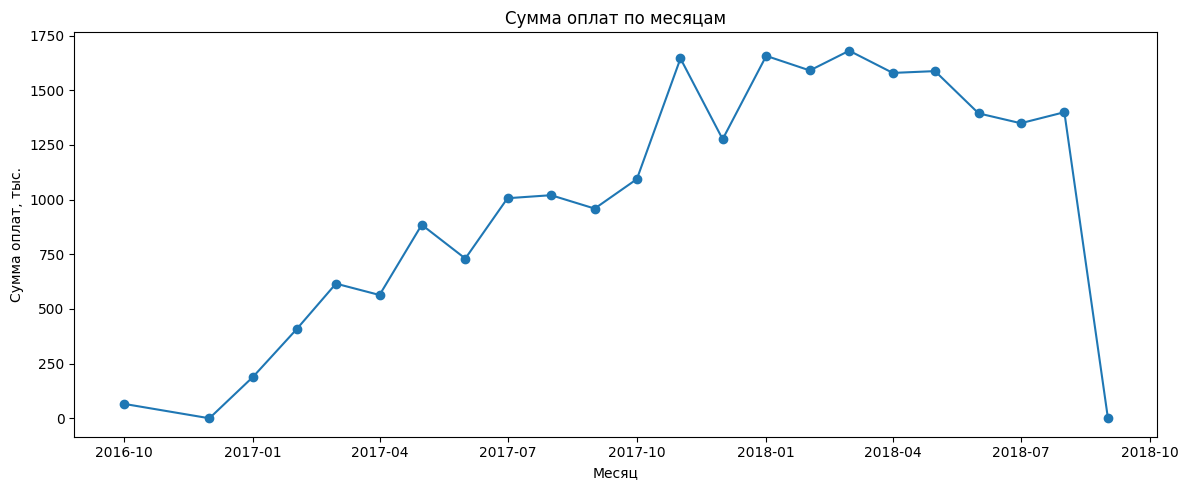

In [181]:
monthly_payments_plot = monthly_payments.copy()
monthly_payments_plot['order_month_dt'] = pd.to_datetime(monthly_payments_plot['order_month'])

monthly_payments_plot['total_payment_value_k'] = monthly_payments_plot['total_payment_value'] / 1000

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_payments_plot['order_month_dt'],
    monthly_payments_plot['total_payment_value_k'],
    marker='o'
)
plt.title('Сумма оплат по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма оплат, тыс.')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

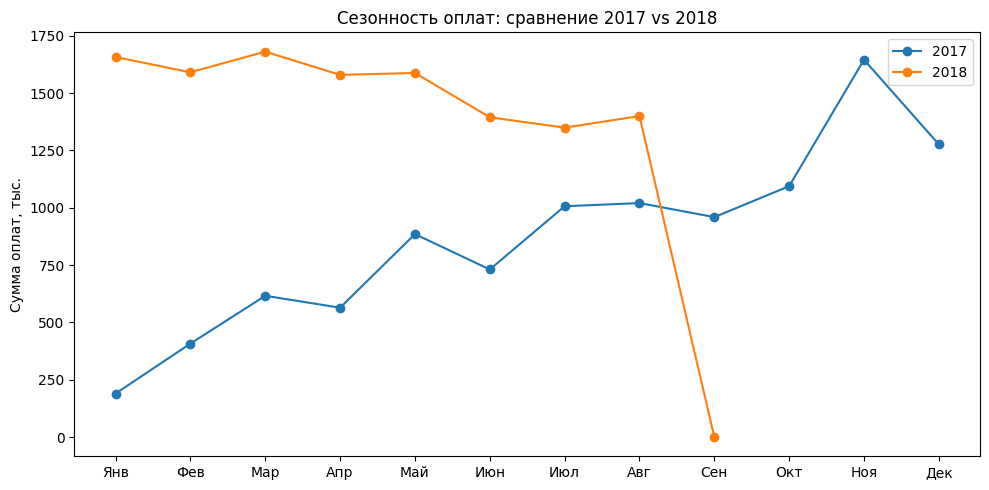

In [186]:
df = monthly_payments.copy()
df['order_month_dt'] = pd.to_datetime(df['order_month'])
df['year'] = df['order_month_dt'].dt.year
df['month'] = df['order_month_dt'].dt.month

df = df[df['year'].isin([2017, 2018])]

pivot = df.pivot(index='month', columns='year', values='total_payment_value')
pivot = pivot.sort_index()

plt.figure(figsize=(10, 5))

plt.plot(pivot.index, pivot[2017] / 1000, marker='o', label='2017')
plt.plot(pivot.index, pivot[2018] / 1000, marker='o', label='2018')

plt.xticks(
    ticks=range(1, 13),
    labels=['Янв','Фев','Мар','Апр','Май','Июн',
            'Июл','Авг','Сен','Окт','Ноя','Дек']
)

plt.ylabel('Сумма оплат, тыс.')
plt.title('Сезонность оплат: сравнение 2017 vs 2018')
plt.legend()
plt.tight_layout()
plt.show()


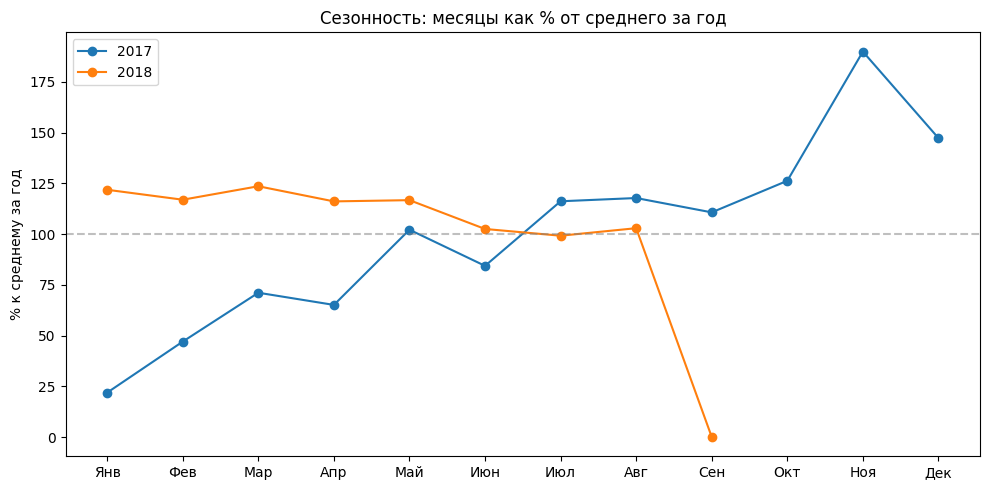

In [ ]:
df = monthly_payments.copy()
df['order_month_dt'] = pd.to_datetime(df['order_month'])
df['year'] = df['order_month_dt'].dt.year
df['month'] = df['order_month_dt'].dt.month

# берём только полные годы, если нужно (например, 2017 и 2018)
df = df[df['year'].isin([2017, 2018])]

# считаем среднее и медиану по году
year_stats = df.groupby('year')['total_payment_value'].agg(
    year_mean='mean',
    year_median='median'
).reset_index()

# мёржим обратно
df = df.merge(year_stats, on='year', how='left')

# считаем проценты к среднему и медиане
df['pct_of_mean'] = df['total_payment_value'] / df['year_mean'] * 100
df['pct_of_median'] = df['total_payment_value'] / df['year_median'] * 100

pivot_mean = df.pivot(index='month', columns='year', values='pct_of_mean').sort_index()

plt.figure(figsize=(10, 5))
plt.plot(pivot_mean.index, pivot_mean[2017], marker='o', label='2017')
plt.plot(pivot_mean.index, pivot_mean[2018], marker='o', label='2018')

plt.xticks(
    ticks=range(1, 13),
    labels=['Янв','Фев','Мар','Апр','Май','Июн',
            'Июл','Авг','Сен','Окт','Ноя','Дек']
)
plt.axhline(100, color='gray', linestyle='--', alpha=0.5)  # линия на уровне среднего
plt.ylabel('% к среднему за год')
plt.title('Сезонность: месяцы как % от среднего за год')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df = monthly_payments.copy()
df['order_month_dt'] = pd.to_datetime(df['order_month'])
df['year'] = df['order_month_dt'].dt.year
df['month'] = df['order_month_dt'].dt.month

# берём только 2017 и 2018
df = df[df['year'].isin([2017, 2018])]

# пивот: месяцы vs годы
table_abs = df.pivot(index='month', columns='year', values='total_payment_value')
table_abs.index = ['Янв','Фев','Мар','Апр','Май','Июн',
                   'Июл','Авг','Сен','Окт','Ноя','Дек'][:len(table_abs)]

# форматирование: разделитель тысяч — пробел
table_abs_formatted = table_abs.map(lambda x: f'{x:,.0f}'.replace(',', ' '))

print(table_abs_formatted)

# чёткой сезонности нет: месяцы 2017 и 2018 ведут себя по‑разному,
# без устойчивого «рисунка» по одинаковым месяцам.

year       2017       2018
Янв     189 584  1 657 056
Фев     407 351  1 590 418
Мар     615 911  1 680 708
Апр     563 937  1 579 179
Май     884 920  1 587 465
Июн     730 638  1 394 327
Июл   1 006 351  1 349 176
Авг   1 020 204  1 399 586
Сен     958 980         66
Окт   1 093 798        nan
Ноя   1 645 278        nan
Дек   1 276 102        nan


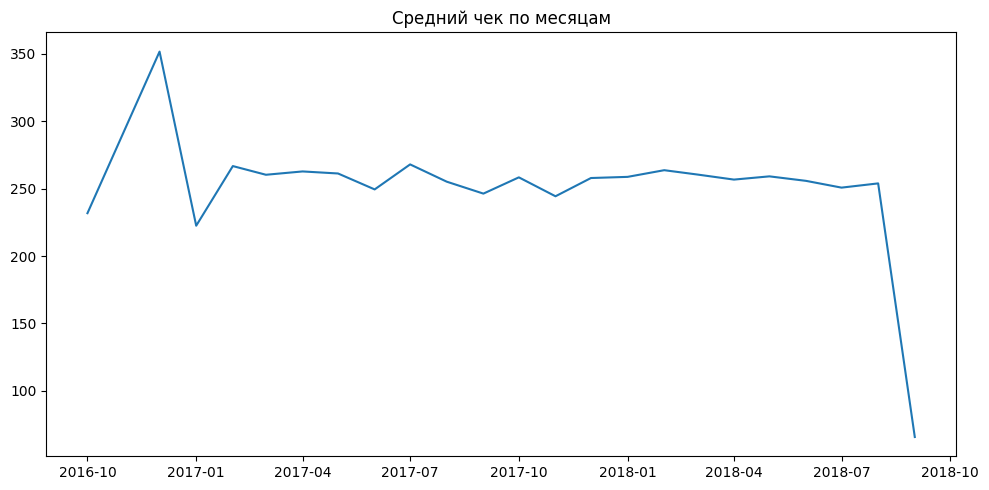

In [204]:
# посмотрим на средний чек

orders = (
    df_p_mid
    .groupby('order_id', as_index=False)
    .agg({
        'payment_value': 'sum',
        'order_month': 'first'
    })
    .rename(columns={'payment_value': 'order_value'})
)

aov_by_month = (
    orders
    .groupby('order_month', as_index=False)
    .agg(avg_order_value=('order_value', 'mean'))
)

aov_by_month['order_month_dt'] = pd.to_datetime(aov_by_month['order_month'])

plt.figure(figsize=(10, 5))
plt.plot(
    aov_by_month['order_month_dt'],
    aov_by_month['avg_order_value']
)
plt.title('Средний чек по месяцам')
plt.tight_layout()
plt.show()

# средний чек стабилен на уровне ~250 без заметной сезонности по месяцам

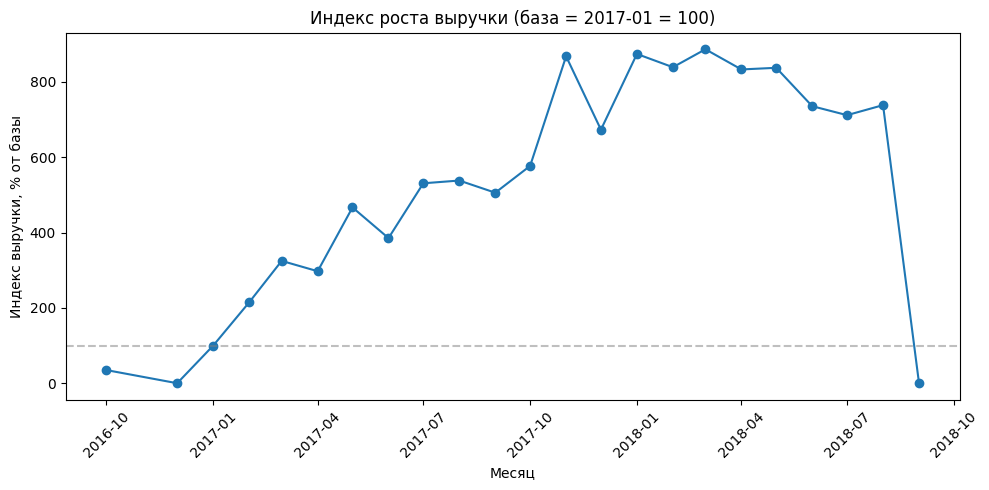

In [ ]:
# посмотрим индекс роста
df = monthly_payments.copy()
df['order_month_dt'] = pd.to_datetime(df['order_month'])

# сортируем по времени
df = df.sort_values('order_month_dt')

# выбираем базовый месяц (можешь сменить на любой)
base_month = '2017-01'
base_value = df.loc[df['order_month'] == base_month, 'total_payment_value'].iloc[0]

# индекс роста относительно базового месяца
df['revenue_index'] = df['total_payment_value'] / base_value * 100


plt.figure(figsize=(10, 5))
plt.plot(
    df['order_month_dt'],
    df['revenue_index'],
    marker='o'
)

plt.axhline(100, color='gray', linestyle='--', alpha=0.5)  # базовый уровень
plt.title(f'Индекс роста выручки (база = {base_month} = 100)')
plt.xlabel('Месяц')
plt.ylabel('Индекс выручки, % от базы')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# компания достаточно быстро и сильно выросла
# и удерживала позиции (данные за сентябрь 2028 года - неполные)

In [ ]:
# итоги по годам
df = monthly_payments.copy()
df['order_month_dt'] = pd.to_datetime(df['order_month'])
df['year'] = df['order_month_dt'].dt.year

revenue_by_year = (
    df
    .groupby('year', as_index=False)['total_payment_value']
    .sum()
    .rename(columns={'total_payment_value': 'revenue'})
)

revenue_by_year['revenue_fmt'] = revenue_by_year['revenue'].map(
    lambda x: f'{x:,.0f}'.replace(',', ' ')
)

revenue_by_year[['revenue_fmt']]

# 2017: выручка около 10.4 млн,
# 2018: около 12.2 млн, то есть +1.8 млн год к году,
# рост примерно на 17–18 % (при учёте, что 2018 обрезан по сентябрь)

,revenue_fmt
0,66 882
1,10 393 054
2,12 237 981


In [ ]:
# средний месячный рост
# отсечём 2016-10, 2016-12 и 2018-09 как неполные
df_growth = df[
    (df['order_month'] >= '2017-01') &
    (df['order_month'] <= '2018-08')
].sort_values('order_month_dt')

start_value = df_growth.iloc[0]['total_payment_value']
end_value = df_growth.iloc[-1]['total_payment_value']

n_months = len(df_growth) - 1

cmgr = (end_value / start_value) ** (1 / n_months) - 1
cmgr_pct = round(cmgr * 100, 0)
cmgr_pct

# Между январём 2017 и августом 2018 средний месячный рост выручки составил примерно 11 %.
# Это значит, что бизнес в среднем каждый месяц становился на 11 % больше по выручке.

np.float64(11.0)